# Model fitting 2: Only SSC and extended radio jet, MCMC without minimizer step

In [1]:
#import warnings
#warnings.filterwarnings('ignore')

import matplotlib.pylab as plt
import jetset
from jetset.test_data_helper import  test_SEDs
from jetset.data_loader import ObsData,Data
from jetset.plot_sedfit import PlotSED
from jetset.test_data_helper import  test_SEDs

In [2]:
print(jetset.__version__)

1.4.0rc2


In [3]:
test_SEDs

['/Users/orion/miniforge3/envs/jetset/lib/python3.12/site-packages/jetset/test_data/SEDs_data/SED_3C345.ecsv',
 '/Users/orion/miniforge3/envs/jetset/lib/python3.12/site-packages/jetset/test_data/SEDs_data/SED_MW_Mrk421_EBL_DEABS.ecsv',
 '/Users/orion/miniforge3/envs/jetset/lib/python3.12/site-packages/jetset/test_data/SEDs_data/SED_MW_Mrk501_EBL_ABS.ecsv',
 '/Users/orion/miniforge3/envs/jetset/lib/python3.12/site-packages/jetset/test_data/SEDs_data/SED_MW_Mrk501_EBL_DEABS.ecsv']

## Loading data



In [4]:
print(test_SEDs[1])
data=Data.from_file(test_SEDs[1])


/Users/orion/miniforge3/envs/jetset/lib/python3.12/site-packages/jetset/test_data/SEDs_data/SED_MW_Mrk421_EBL_DEABS.ecsv



***  binning data  ***
---> N bins= 88
---> bin_width= 0.2



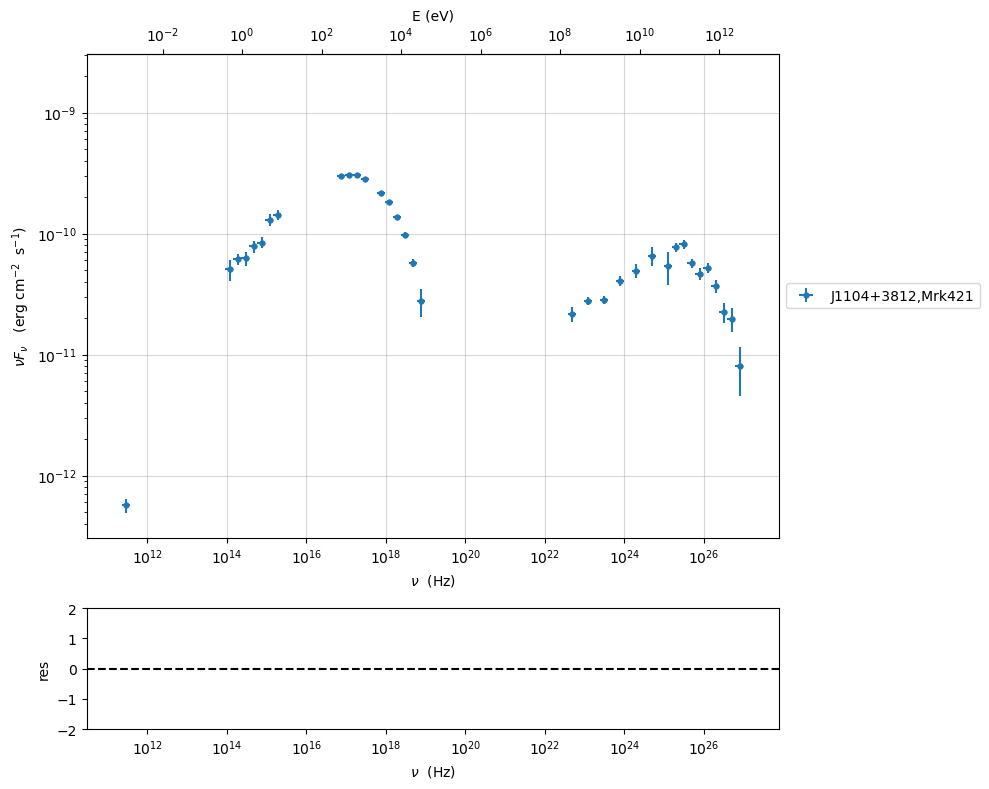

In [5]:
%matplotlib inline
sed_data=ObsData(data_table=data)
sed_data.group_data(bin_width=0.2)

sed_data.add_systematics(0.1,[10.**6,10.**16])
p=sed_data.plot_sed()
#p.setlim(y_min=1E-15,x_min=1E7,x_max=1E29)

In [6]:
sed_data.save('Mrk_401.pkl')

### creating and setting the sampler

In [7]:

from jetset.mcmc_ultranest import UltraNestSampler
from jetset.minimizer import ModelMinimizer


In [8]:
from jetset.jet_model import Jet
from jetset.model_manager import FitModel
fit_model=FitModel(jet=Jet(emitters_distribution='plc'))

/Users/orion/miniforge3/envs/jetset/lib/python3.12/site-packages/jetset/model_manager.py:259: UserWarning: no cosmology defined, using the one from jet FlatLambdaCDM(name="Planck13", H0=67.77 km / (Mpc s), Om0=0.30712, Tcmb0=2.7255 K, Neff=3.046, m_nu=[0.   0.   0.06] eV, Ob0=0.048252)
  warnings.warn(m)


We create a `ModelMinimizer` object directly for the MCMC step, skipping the `.run()` method, replaced by the call of the `prepare_fit` method.

In [9]:
model_minimizer = model_minimizer=ModelMinimizer('mcmc')
model_minimizer.prepare_fit(fit_model,
                            sed_data,
                            nu_fit_start=1E11,
                            nu_fit_stop=1E29,
                            use_UL=True)



filtering data in fit range = [1.000000e+11,1.000000e+29]
data length 34


to speed up the utlranest sampler we make parameters logarithmic:


In [10]:
model_minimizer.fit_model.jet_leptonic.parameters.R.make_log()
model_minimizer.fit_model.jet_leptonic.parameters.B.make_log()
model_minimizer.fit_model.jet_leptonic.parameters.N.make_log()
model_minimizer.fit_model.jet_leptonic.parameters.gmax.make_log()
model_minimizer.fit_model.jet_leptonic.parameters.gmin.make_log()
model_minimizer.fit_model.jet_leptonic.parameters.gamma_cut.make_log()
model_minimizer.fit_model.jet_leptonic.parameters.z_cosm.freeze()


In [11]:
model_minimizer.fit_model.parameters

model name,name,par type,units,val,phys. bound. min,phys. bound. max,log,frozen
jet_leptonic,R,region_size,cm,1.569897e+01,3.000000e+00,3.000000e+01,True,False
jet_leptonic,R_H,region_position,cm,1.000000e+17,0.000000e+00,--,False,True
jet_leptonic,B,magnetic_field,gauss,-1.000000e+00,-2.000000e+02,--,True,False
jet_leptonic,NH_cold_to_rel_e,cold_p_to_rel_e_ratio,,1.000000e+00,0.000000e+00,--,False,True
jet_leptonic,beam_obj,beaming,,1.000000e+01,1.000000e-04,--,False,False
jet_leptonic,z_cosm,redshift,,1.000000e-01,0.000000e+00,--,False,True
jet_leptonic,gmin,low-energy-cut-off,lorentz-factor*,3.010300e-01,0.000000e+00,9.000000e+00,True,False
jet_leptonic,gmax,high-energy-cut-off,lorentz-factor*,6.000000e+00,0.000000e+00,1.500000e+01,True,False
jet_leptonic,N,emitters_density,1 / cm3,2.000000e+00,-2.000000e+02,--,True,False
jet_leptonic,gamma_cut,turn-over-energy,lorentz-factor*,4.000000e+00,0.000000e+00,9.000000e+00,True,False


None

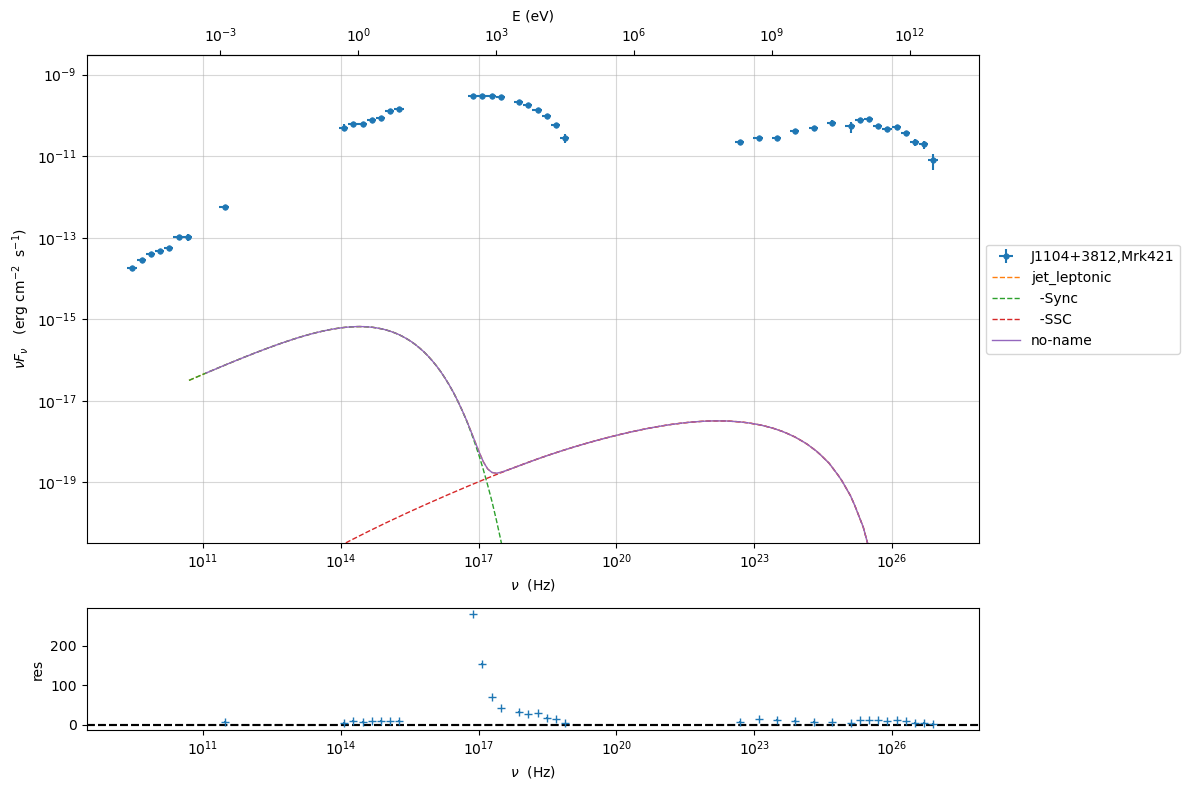

In [12]:
model_minimizer.fit_model.eval()
p=model_minimizer.fit_model.plot_model(sed_data=sed_data)

In [13]:

mcmc=UltraNestSampler(model_minimizer)

In [14]:
mcmc.model.parameters

model name,name,par type,units,val,phys. bound. min,phys. bound. max,log,frozen
jet_leptonic,gmin,low-energy-cut-off,lorentz-factor*,3.010300e-01,0.000000e+00,9.000000e+00,True,False
jet_leptonic,gmax,high-energy-cut-off,lorentz-factor*,6.000000e+00,0.000000e+00,1.500000e+01,True,False
jet_leptonic,N,emitters_density,1 / cm3,2.000000e+00,-2.000000e+02,--,True,False
jet_leptonic,gamma_cut,turn-over-energy,lorentz-factor*,4.000000e+00,0.000000e+00,9.000000e+00,True,False
jet_leptonic,p,LE_spectral_slope,,2.000000e+00,-1.000000e+01,1.000000e+01,False,False
jet_leptonic,R,region_size,cm,1.569897e+01,3.000000e+00,3.000000e+01,True,False
jet_leptonic,R_H,region_position,cm,1.000000e+17,0.000000e+00,--,False,True
jet_leptonic,B,magnetic_field,gauss,-1.000000e+00,-2.000000e+02,--,True,False
jet_leptonic,NH_cold_to_rel_e,cold_p_to_rel_e_ratio,,1.000000e+00,0.000000e+00,--,False,True
jet_leptonic,beam_obj,beaming,,1.000000e+01,1.000000e-04,--,False,False


None

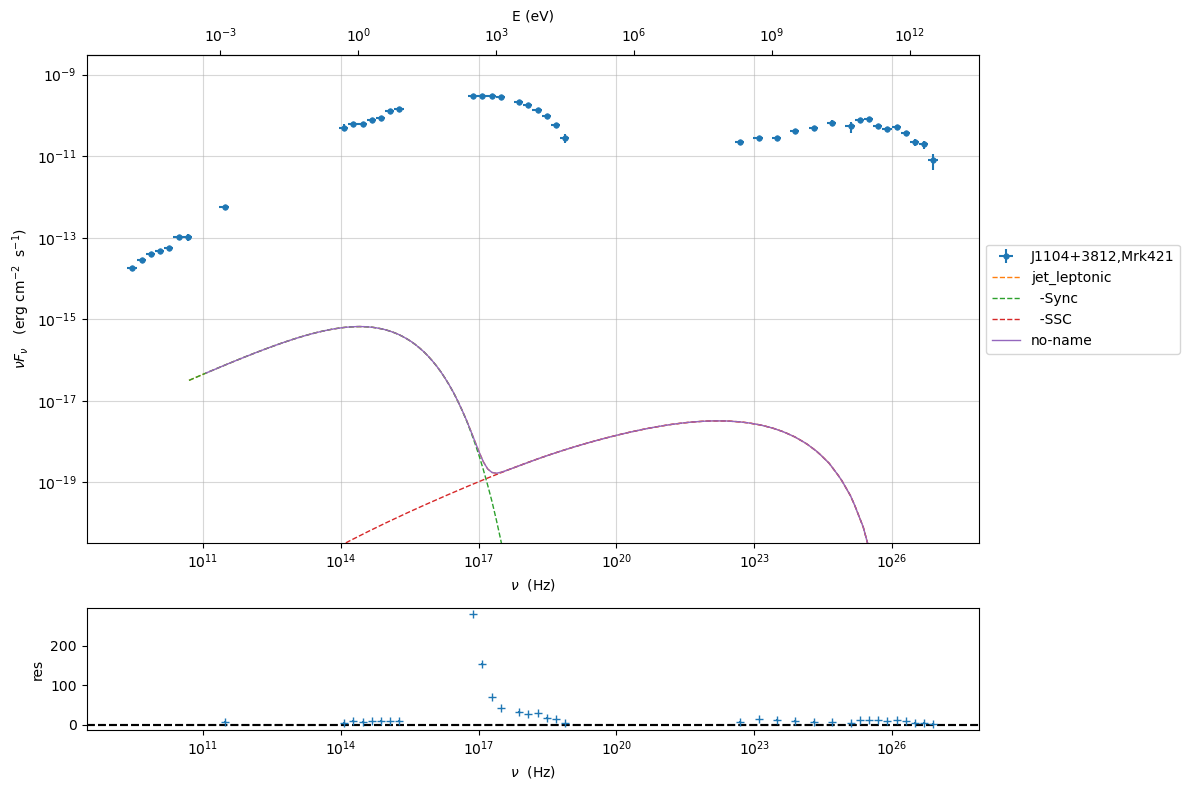

In [15]:
mcmc.model.eval()
mcmc.model.plot_model(sed_data=sed_data)

You can inspect the mcmc parameters using:

In [16]:
mcmc.sampler_parameters

model name,name,val,log,bestfit mcmc,q16,q50,q84,mcmc bound min,mcmc bound max,frozen
str12,str16,float64,bool,float64,float64,float64,float64,float64,float64,bool
jet_leptonic,gmin,3.010300e-01,True,3.010300e-01,--,--,--,0.000000e+00,9.000000e+00,False
jet_leptonic,gmax,6.000000e+00,True,6.000000e+00,--,--,--,0.000000e+00,1.500000e+01,False
jet_leptonic,N,2.000000e+00,True,2.000000e+00,--,--,--,-2.000000e+02,--,False
jet_leptonic,gamma_cut,4.000000e+00,True,4.000000e+00,--,--,--,0.000000e+00,9.000000e+00,False
jet_leptonic,p,2.000000e+00,False,2.000000e+00,--,--,--,-1.000000e+01,1.000000e+01,False
jet_leptonic,R,1.569897e+01,True,1.569897e+01,--,--,--,3.000000e+00,3.000000e+01,False
jet_leptonic,B,-1.000000e+00,True,-1.000000e+00,--,--,--,-2.000000e+02,--,False
jet_leptonic,beam_obj,1.000000e+01,False,1.000000e+01,--,--,--,1.000000e-04,--,False
jet_leptonic,R_H,1.000000e+17,False,--,--,--,--,0.000000e+00,--,True


In [17]:
mcmc.model.parameters.best_fit_par_table

model name,name,val,bestfit val,err +,err -,start val,fit range min,fit range max,frozen
str12,str16,float64,float64,float64,float64,float64,float64,float64,bool
jet_leptonic,gmin,3.010300e-01,--,--,--,3.010300e-01,0.000000e+00,9.000000e+00,False
jet_leptonic,gmax,6.000000e+00,--,--,--,6.000000e+00,0.000000e+00,1.500000e+01,False
jet_leptonic,N,2.000000e+00,--,--,--,2.000000e+00,-2.000000e+02,--,False
jet_leptonic,gamma_cut,4.000000e+00,--,--,--,4.000000e+00,0.000000e+00,9.000000e+00,False
jet_leptonic,p,2.000000e+00,--,--,--,2.000000e+00,-1.000000e+01,1.000000e+01,False
jet_leptonic,R,1.569897e+01,--,--,--,1.569897e+01,3.000000e+00,3.000000e+01,False
jet_leptonic,R_H,1.000000e+17,--,--,--,1.000000e+17,0.000000e+00,--,True
jet_leptonic,B,-1.000000e+00,--,--,--,-1.000000e+00,-2.000000e+02,--,False
jet_leptonic,NH_cold_to_rel_e,1.000000e+00,--,--,--,1.000000e+00,0.000000e+00,--,True


If you want to exclude or include parameters from the samplers just freeze/free them 

In [18]:
mcmc.model.jet_leptonic.parameters.gmax.freeze()
mcmc.model.jet_leptonic.parameters.gmax.val=7

mcmc.set_bounds(par_name='p',comp_name='jet_leptonic',par_bounds=[1.5,3.5])
mcmc.set_bounds(par_name='N',comp_name='jet_leptonic',par_bounds=[-3,3])
mcmc.set_bounds(par_name='R',comp_name='jet_leptonic',par_bounds=[15,17])
mcmc.set_bounds(par_name='beam_obj',comp_name='jet_leptonic',par_bounds=[10,50])


mcmc.set_bounds(par_name='gmin',comp_name='jet_leptonic',par_bounds=[0,3.3])
mcmc.set_bounds(par_name='gamma_cut',comp_name='jet_leptonic',par_bounds=[3,6])
mcmc.set_bounds(par_name='B',comp_name='jet_leptonic',par_bounds=[-3,0])
 


par: p  ref value:  2.0  mcmc bounds: [1.5, 3.5]
par: N  ref value:  2.0  mcmc bounds: [np.float64(-3.0), np.float64(3.0)]
par: R  ref value:  15.698970004336019  mcmc bounds: [np.float64(15.0), np.float64(17.0)]
par: beam_obj  ref value:  10.0  mcmc bounds: [10, 50]
par: gmin  ref value:  0.3010299956639812  mcmc bounds: [np.float64(0.0), np.float64(3.3)]
par: gamma_cut  ref value:  4.0  mcmc bounds: [np.float64(3.0), np.float64(6.0)]
par: B  ref value:  -1.0  mcmc bounds: [np.float64(-3.0), np.float64(0.0)]


In [19]:
mcmc.model.parameters

model name,name,par type,units,val,phys. bound. min,phys. bound. max,log,frozen
jet_leptonic,gmin,low-energy-cut-off,lorentz-factor*,3.010300e-01,0.000000e+00,9.000000e+00,True,False
jet_leptonic,gmax,high-energy-cut-off,lorentz-factor*,7.000000e+00,0.000000e+00,1.500000e+01,True,True
jet_leptonic,N,emitters_density,1 / cm3,2.000000e+00,-2.000000e+02,--,True,False
jet_leptonic,gamma_cut,turn-over-energy,lorentz-factor*,4.000000e+00,0.000000e+00,9.000000e+00,True,False
jet_leptonic,p,LE_spectral_slope,,2.000000e+00,-1.000000e+01,1.000000e+01,False,False
jet_leptonic,R,region_size,cm,1.569897e+01,3.000000e+00,3.000000e+01,True,False
jet_leptonic,R_H,region_position,cm,1.000000e+17,0.000000e+00,--,False,True
jet_leptonic,B,magnetic_field,gauss,-1.000000e+00,-2.000000e+02,--,True,False
jet_leptonic,NH_cold_to_rel_e,cold_p_to_rel_e_ratio,,1.000000e+00,0.000000e+00,--,False,True
jet_leptonic,beam_obj,beaming,,1.000000e+01,1.000000e-04,--,False,False


None

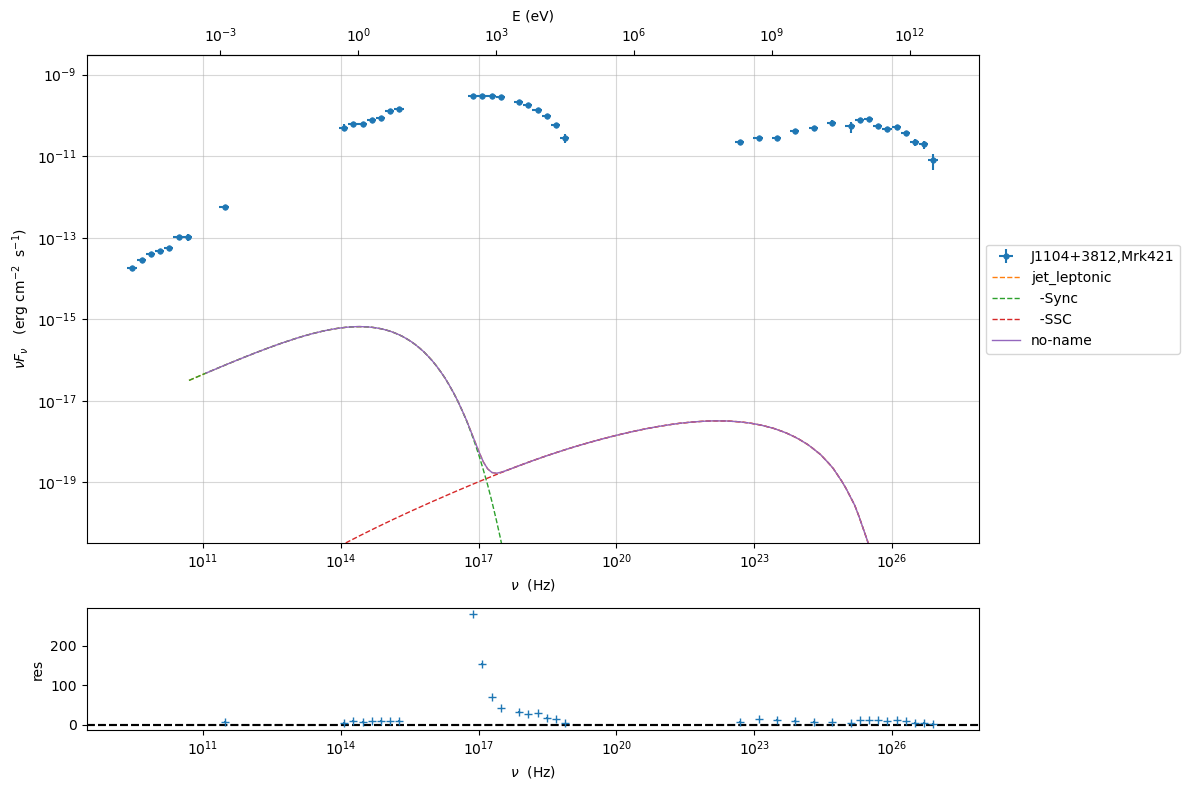

In [20]:
mcmc.model.eval()
mcmc.model.plot_model(sed_data=sed_data)

In [21]:
mcmc.sampler_parameters

model name,name,val,log,bestfit mcmc,q16,q50,q84,mcmc bound min,mcmc bound max,frozen
str12,str16,float64,bool,float64,float64,float64,float64,float64,float64,bool
jet_leptonic,gmin,3.010300e-01,True,3.010300e-01,--,--,--,0.000000e+00,3.300000e+00,False
jet_leptonic,N,2.000000e+00,True,2.000000e+00,--,--,--,-3.000000e+00,3.000000e+00,False
jet_leptonic,gamma_cut,4.000000e+00,True,4.000000e+00,--,--,--,3.000000e+00,6.000000e+00,False
jet_leptonic,p,2.000000e+00,False,2.000000e+00,--,--,--,1.500000e+00,3.500000e+00,False
jet_leptonic,R,1.569897e+01,True,1.569897e+01,--,--,--,1.500000e+01,1.700000e+01,False
jet_leptonic,B,-1.000000e+00,True,-1.000000e+00,--,--,--,-3.000000e+00,0.000000e+00,False
jet_leptonic,beam_obj,1.000000e+01,False,1.000000e+01,--,--,--,1.000000e+01,5.000000e+01,False
jet_leptonic,gmax,7.000000e+00,True,--,--,--,--,0.000000e+00,1.500000e+01,True
jet_leptonic,R_H,1.000000e+17,False,--,--,--,--,0.000000e+00,--,True


The configuration in the cell below if for quick test. For a more robust analysis, please leave `min_num_live_points`, `nsteps`, `max_num_improvement_loops`, and `min_ess` to their default values 

Tor run ultranest via openmpi, you have to install
- mpi4py (pip/mamba install mpi4py)
- OpenMPI (https://docs.open-mpi.org/en/main/installing-open-mpi/quickstart.html#binary-packages)

In [22]:
from jetset.mcmc_ultranest import UltraNestSampler,run_open_mpi

mcmc=run_open_mpi(mcmc,
                 n_proc=8, #it runs 8 parallel processes, speeding up the sampler, increase n_proc value up to the number of cores/cpus depending on yor machine/cluster setup
                 min_num_live_points=64,
                 nsteps=1,
                 max_num_improvement_loops=1, 
                 min_ess=100,
                 num_c_threads=0, #when using openmpi do not enable c-threads
)

====== ultranest script ========
from jetset.mcmc_ultranest import UltraNestSampler
mcmc=UltraNestSampler.load('sampler.pkl')

mcmc.model.set_num_c_threads(0)

mcmc.run_sampler(
                min_num_live_points=64,
                nsteps=1,
                max_num_improvement_loops=1,
                min_ess=100.0,
            )
    
mcmc.save('sampler.pkl')

executing mpirun  -np 8 python run_jetset_ultranest.py
Creating directory for new run ultranest_no-name/run1
ultranest run starting

ultranest run starting

ultranest run starting

ultranest run starting

ultranest run starting

ultranest run starting

ultranest run starting

ultranest run starting

[ultranest] Sampling 64 live points from prior ...


Mono-modal Volume: ~exp(-0.89) * Expected Volume: exp(0.00) Quality: ok

gmin     :  +3.3e-06|******** ** ** ******* * *   ** ******** * **** | +3.3e+00
N        :      -3.0| ********  * ** * **** ******* *  *** ****** ***|     +3.0
gamma_cut:      +3.0| *   * ***** ** **  ** ****

[<Figure size 1000x2100 with 7 Axes>]

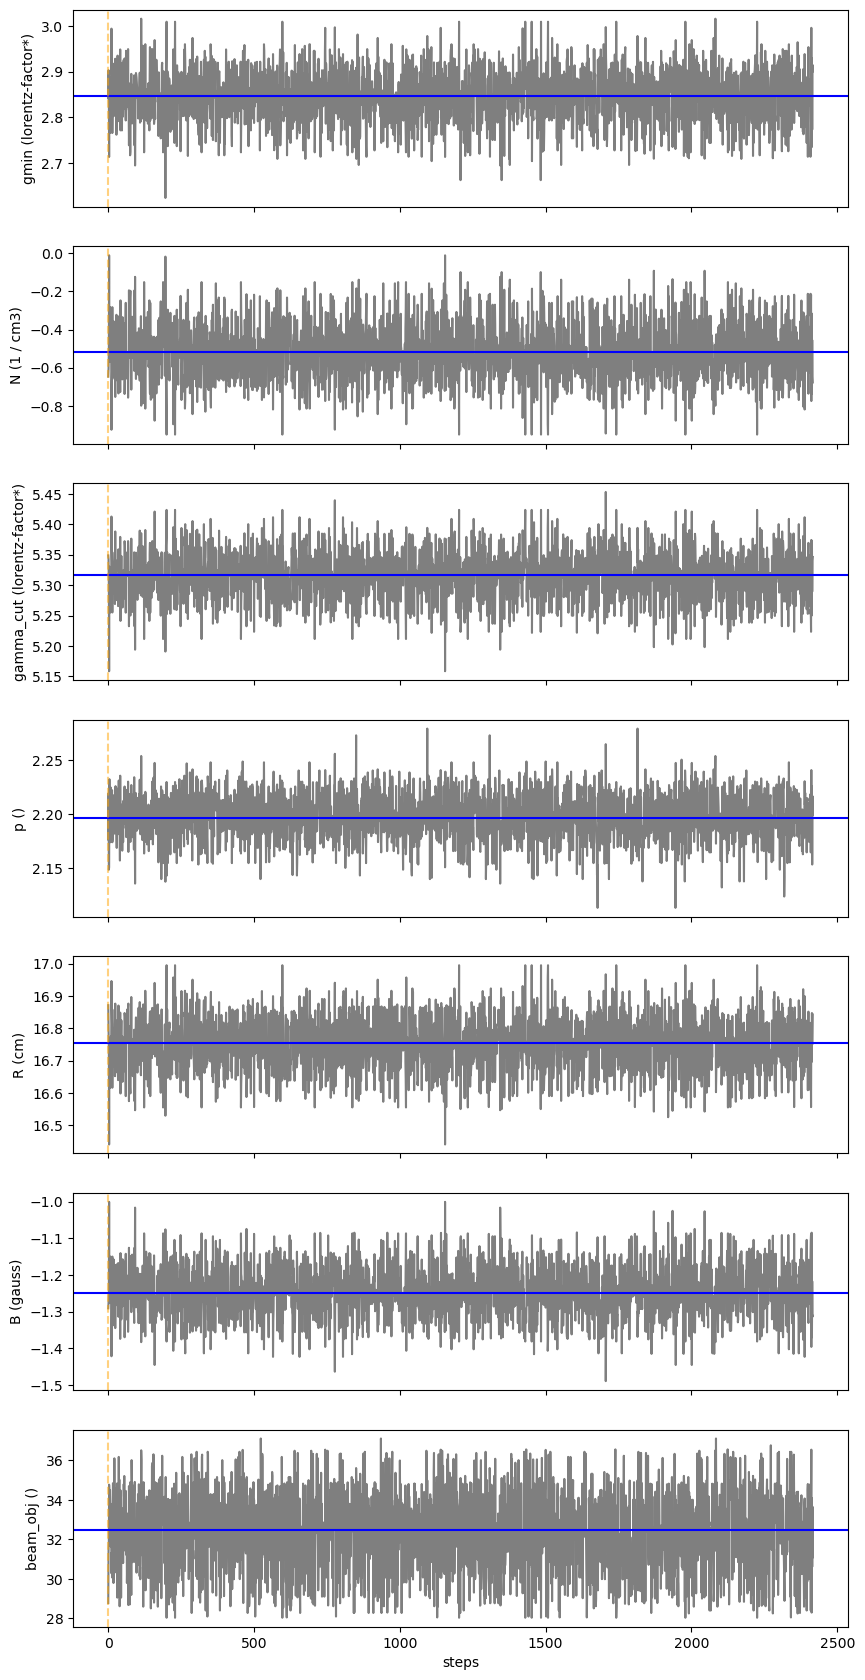

In [23]:
mcmc.plot_chain()

In [24]:
#mcmc.tune_burnin(tau_cor_coeff=4)

Showing the MCMC parameters. Now MCMC bestfit values are updated to the best-fit MCMC solution


In [25]:
mcmc.sampler_parameters

model name,name,val,log,bestfit mcmc,q16,q50,q84,mcmc bound min,mcmc bound max,frozen
str12,str16,float64,bool,float64,float64,float64,float64,float64,float64,bool
jet_leptonic,gmin,2.862132e+00,True,2.862132e+00,2.793184e+00,2.847179e+00,2.901346e+00,0.000000e+00,3.300000e+00,False
jet_leptonic,N,-5.869194e-01,True,-5.869194e-01,-6.613947e-01,-5.177216e-01,-3.608506e-01,-3.000000e+00,3.000000e+00,False
jet_leptonic,gamma_cut,5.340953e+00,True,5.340953e+00,5.277429e+00,5.316390e+00,5.354219e+00,3.000000e+00,6.000000e+00,False
jet_leptonic,p,2.200548e+00,False,2.200548e+00,2.176658e+00,2.196339e+00,2.220571e+00,1.500000e+00,3.500000e+00,False
jet_leptonic,R,1.679884e+01,True,1.679884e+01,1.666789e+01,1.675326e+01,1.684003e+01,1.500000e+01,1.700000e+01,False
jet_leptonic,B,-1.290284e+00,True,-1.290284e+00,-1.314047e+00,-1.249120e+00,-1.174494e+00,-3.000000e+00,0.000000e+00,False
jet_leptonic,beam_obj,3.201161e+01,False,3.201161e+01,3.005475e+01,3.247335e+01,3.445879e+01,1.000000e+01,5.000000e+01,False
jet_leptonic,gmax,7.000000e+00,True,--,--,--,--,0.000000e+00,1.500000e+01,True
jet_leptonic,R_H,1.000000e+17,False,--,--,--,--,0.000000e+00,--,True


### plotting the posterior corner plot

To have a better rendering on the scatter plot, we redefine the plot labels

In [26]:
mcmc.set_plot_label('N',r'log($N$)',comp_name='jet_leptonic')
mcmc.set_plot_label('R',r'log($R$)',comp_name='jet_leptonic')
mcmc.set_plot_label('B',r'log($B$)',comp_name='jet_leptonic')

mcmc.set_plot_label('gmin',r'log($\gamma_{\rm min}$)',comp_name='jet_leptonic')
mcmc.set_plot_label('p',r'$p$',comp_name='jet_leptonic')
#mcmc.set_plot_label('r',r'$r$',comp_name='jet_leptonic')
mcmc.set_plot_label('gamma_cut',r'$\gamma_{\rm cut}$',comp_name='jet_leptonic')
mcmc.set_plot_label('beam_obj',r'$\delta$',comp_name='jet_leptonic')



the code below lets you tuning the output

1) mpl.rcParams['figure.dpi'] if you increase it you get a better definition
2) title_fmt=".2E" this is the format for python, 2 significant digits, scientific notation
3) title_kwargs=dict(fontsize=12) you can change the fontsize

Per-component corner plot

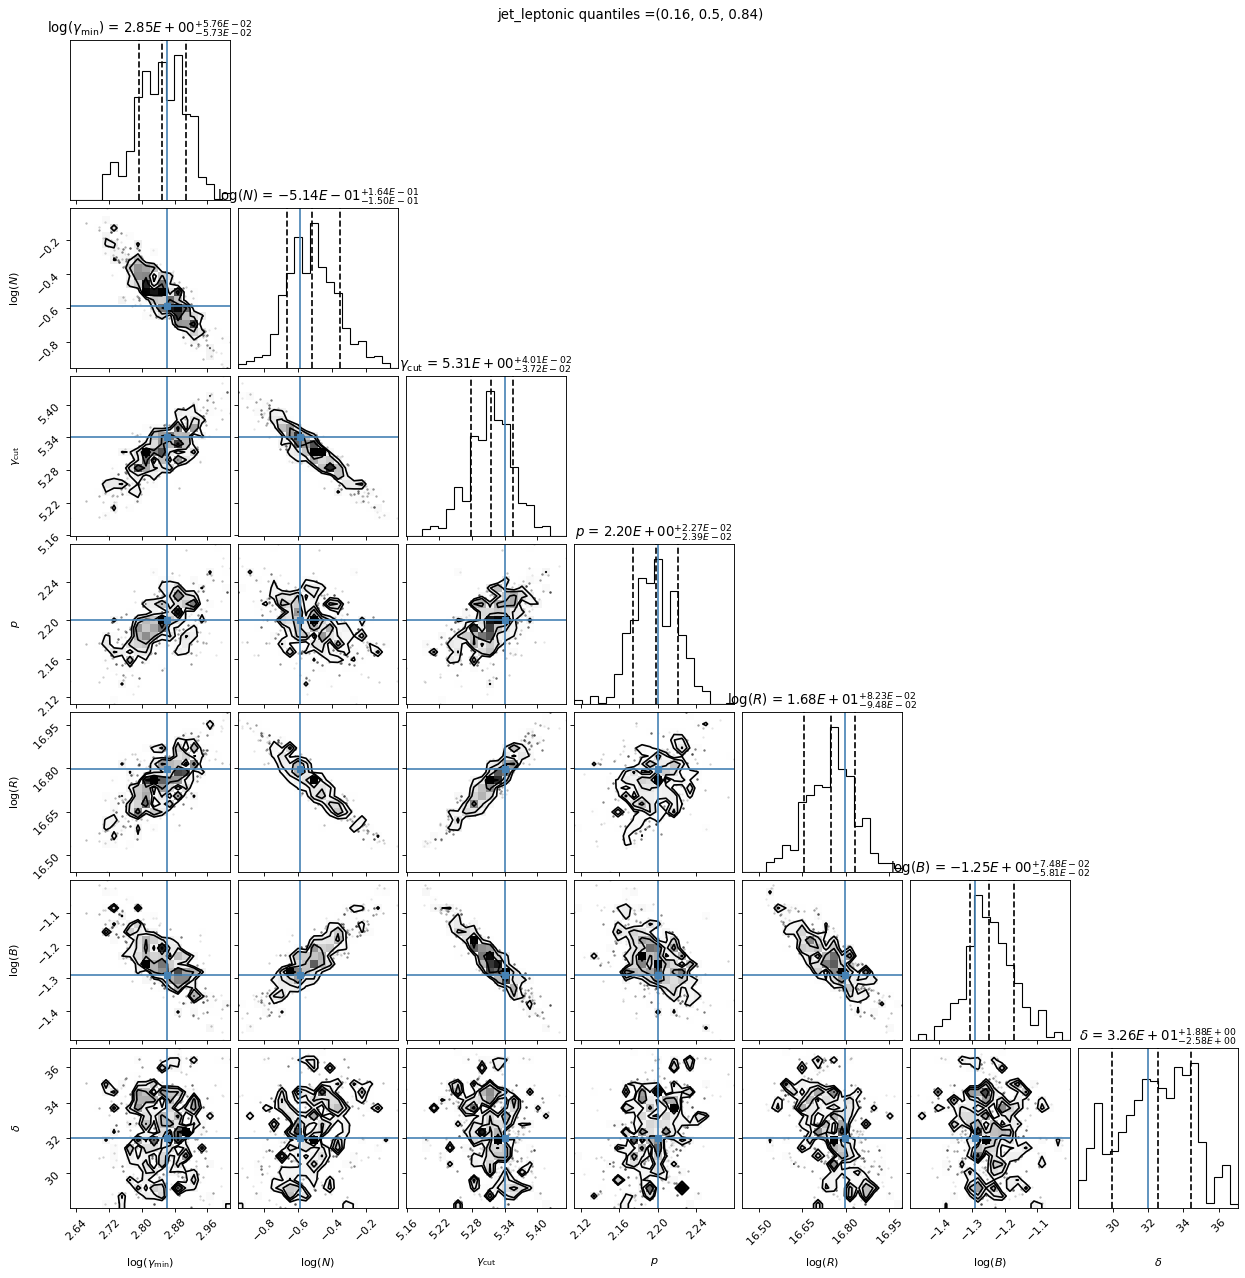

In [27]:
import matplotlib as mpl

mpl.rcParams['figure.dpi'] = 80
f=mcmc.corner_plot(quantiles=(0.16, 0.5, 0.84),title_kwargs=dict(fontsize=12),title_fmt=".2E",use_math_text=True)

Global corner plot, pass `per_component=False`


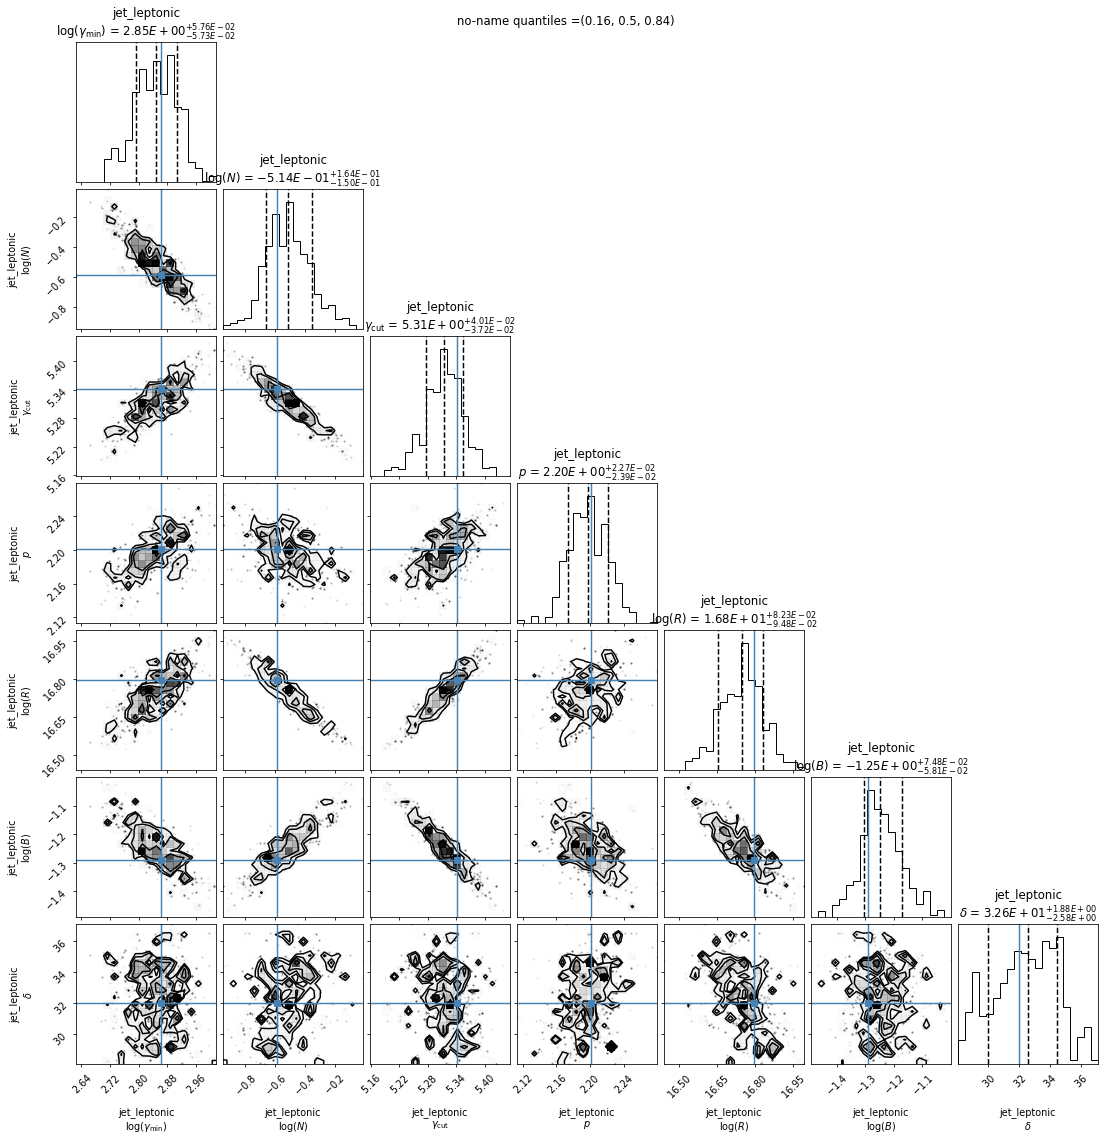

In [28]:
mpl.rcParams['figure.dpi'] = 70
f=mcmc.corner_plot(quantiles=(0.16, 0.5, 0.84),title_kwargs=dict(fontsize=12),title_fmt=".2E",use_math_text=True,per_component=False)

### plotting the model

To plot the sampled model range against the input mcmc best-fit model

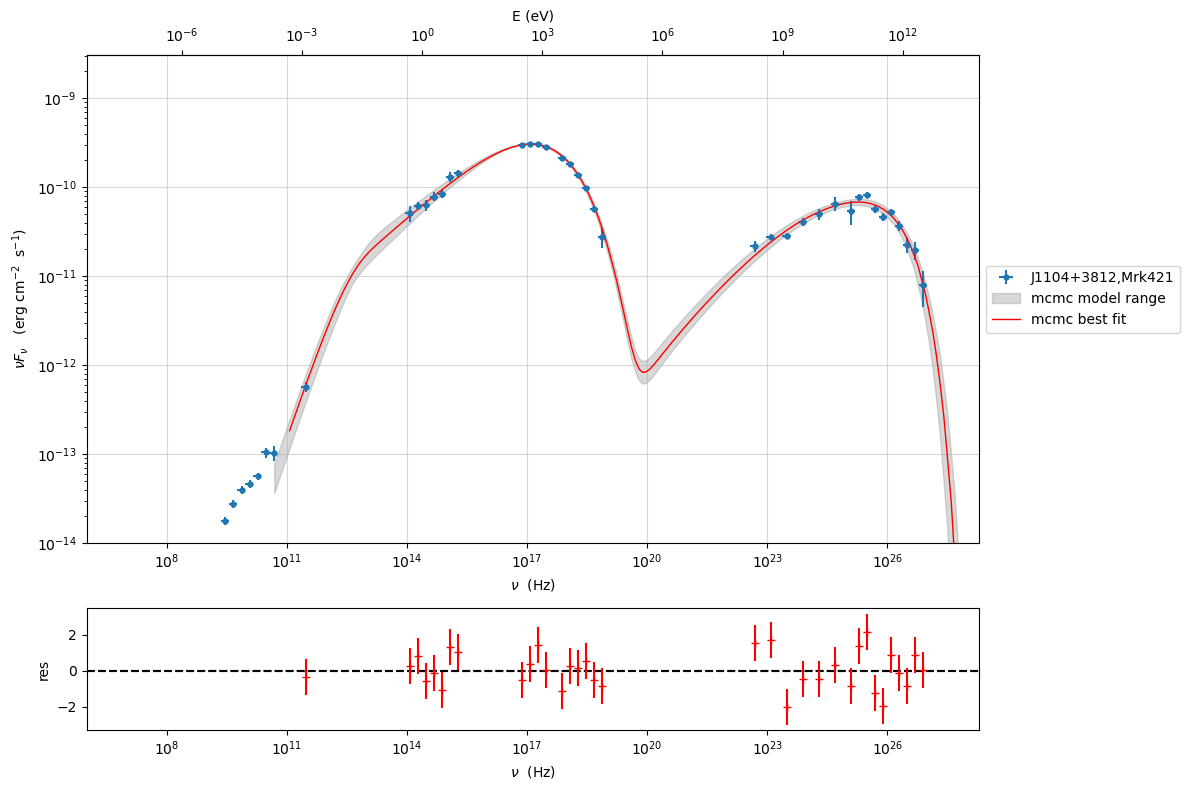

In [29]:

from jetset.data_loader import ObsData
sed_data=ObsData.load('Mrk_401.pkl')
mpl.rcParams['figure.dpi'] = 80
p=mcmc.plot_model(sed_data=sed_data,fit_range=[1E11,1E29],size=600)
p.setlim(y_min=1E-14,x_min=1E6,x_max=2E28)

To plot the mcmc best-fit model providing quantiles. The size parameter defines the number of samples to use to extract the quantiles. I am using a size equal to the number of steps

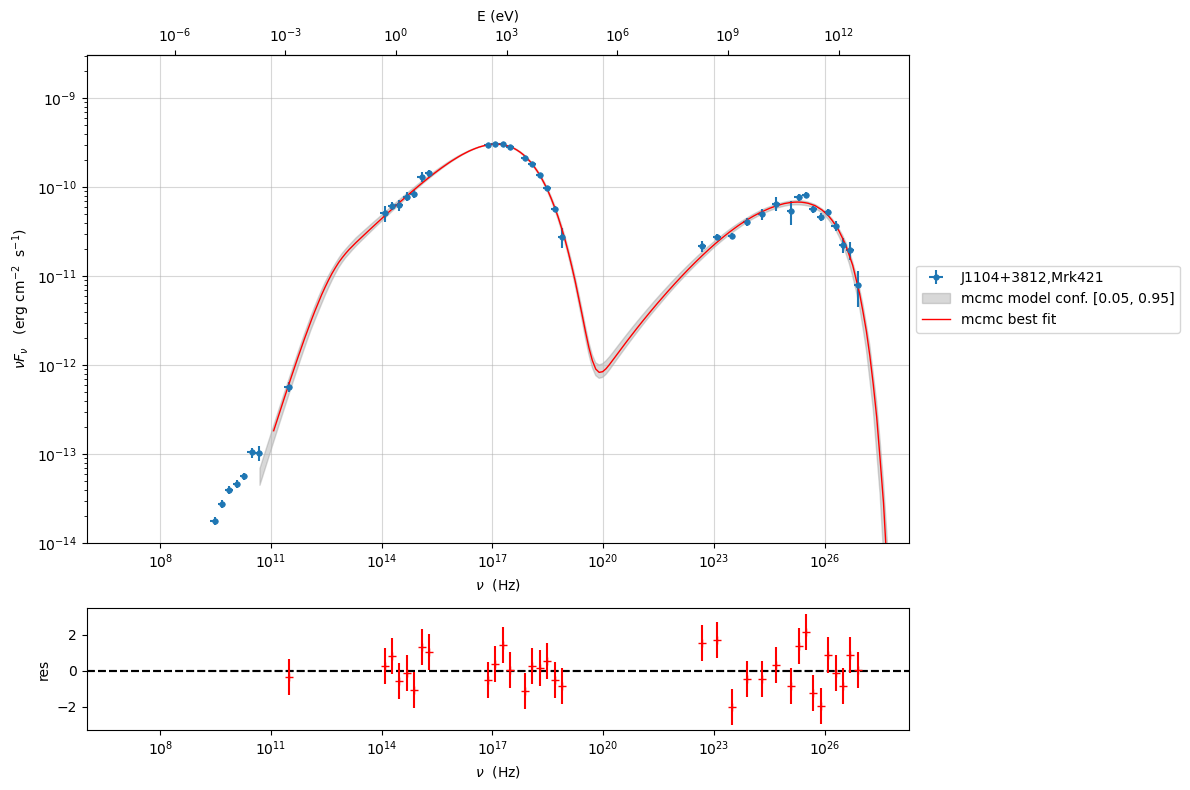

In [30]:
mpl.rcParams['figure.dpi'] = 80
p=mcmc.plot_model(sed_data=sed_data,fit_range=[1E11, 2E29],size=100,quantiles=[0.05,0.95])
p.setlim(y_min=1E-14,x_min=1E6,x_max=2E28)

If you want to plot also the model components, pass the argument `plot_components=True`

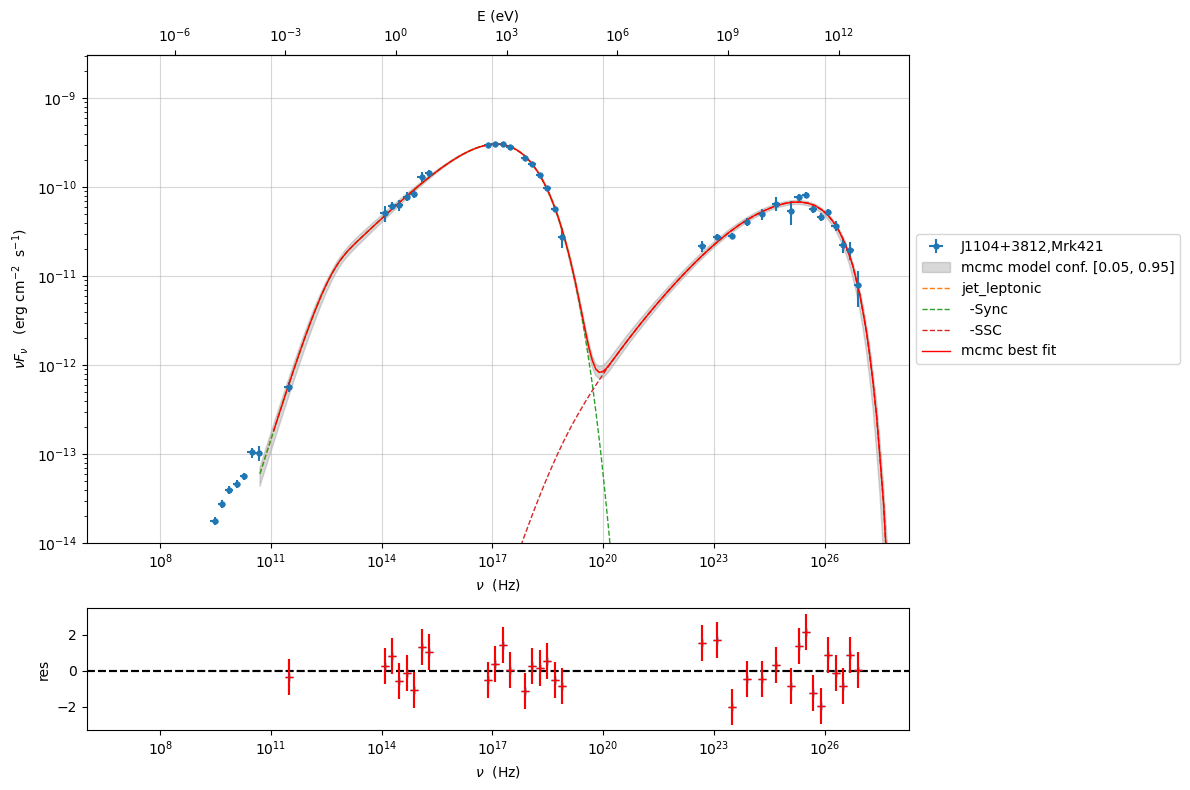

In [31]:
mpl.rcParams['figure.dpi'] = 80
p=mcmc.plot_model(sed_data=sed_data,fit_range=[1E11, 1E29],size=500,quantiles=[0.05,0.95],plot_components=True)
p.setlim(y_min=1E-14,x_min=1E6,x_max=2E28)


To plot the frequentist  best-fit  model range,p roviding quantiles, provide (``plot_mcmc_best_fit_model=False``)

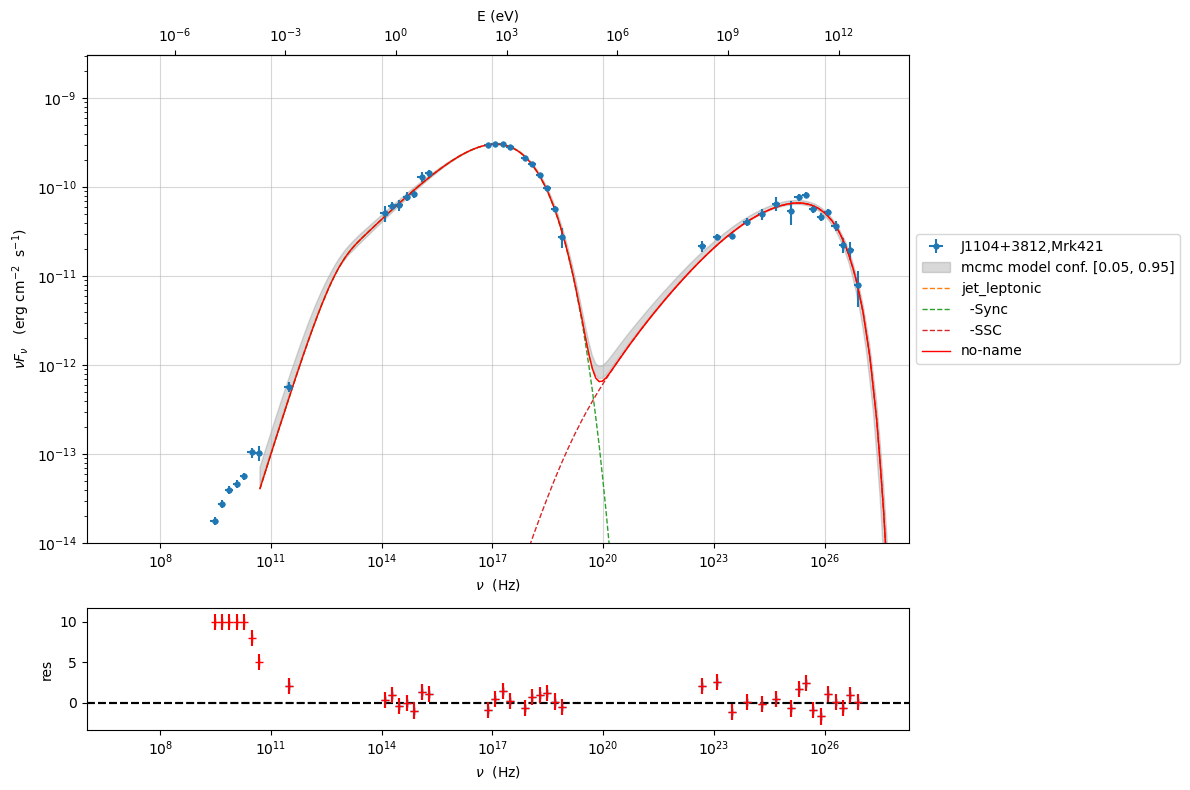

In [32]:
mpl.rcParams['figure.dpi'] = 100
p=mcmc.plot_model(sed_data=sed_data,fit_range=[1E7, 1E29],size=500,quantiles=[0.05,0.95], plot_mcmc_best_fit_model=False,plot_components=True)
p.setlim(y_min=1E-14,x_min=1E6,x_max=2E28)

### plotting chains and individual posteriors

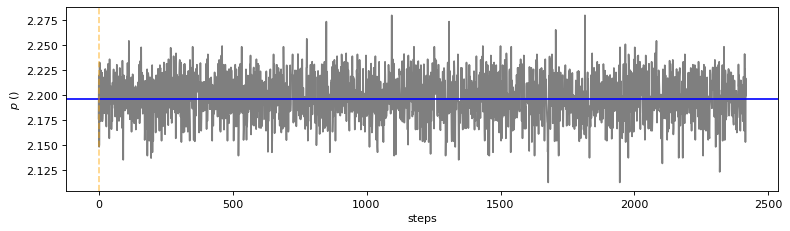

In [33]:
import matplotlib.pylab as plt
import matplotlib as mpl

mpl.rcParams['figure.dpi'] = 80
f=mcmc.plot_chain(par_name='p',log_plot=False)
plt.tight_layout()

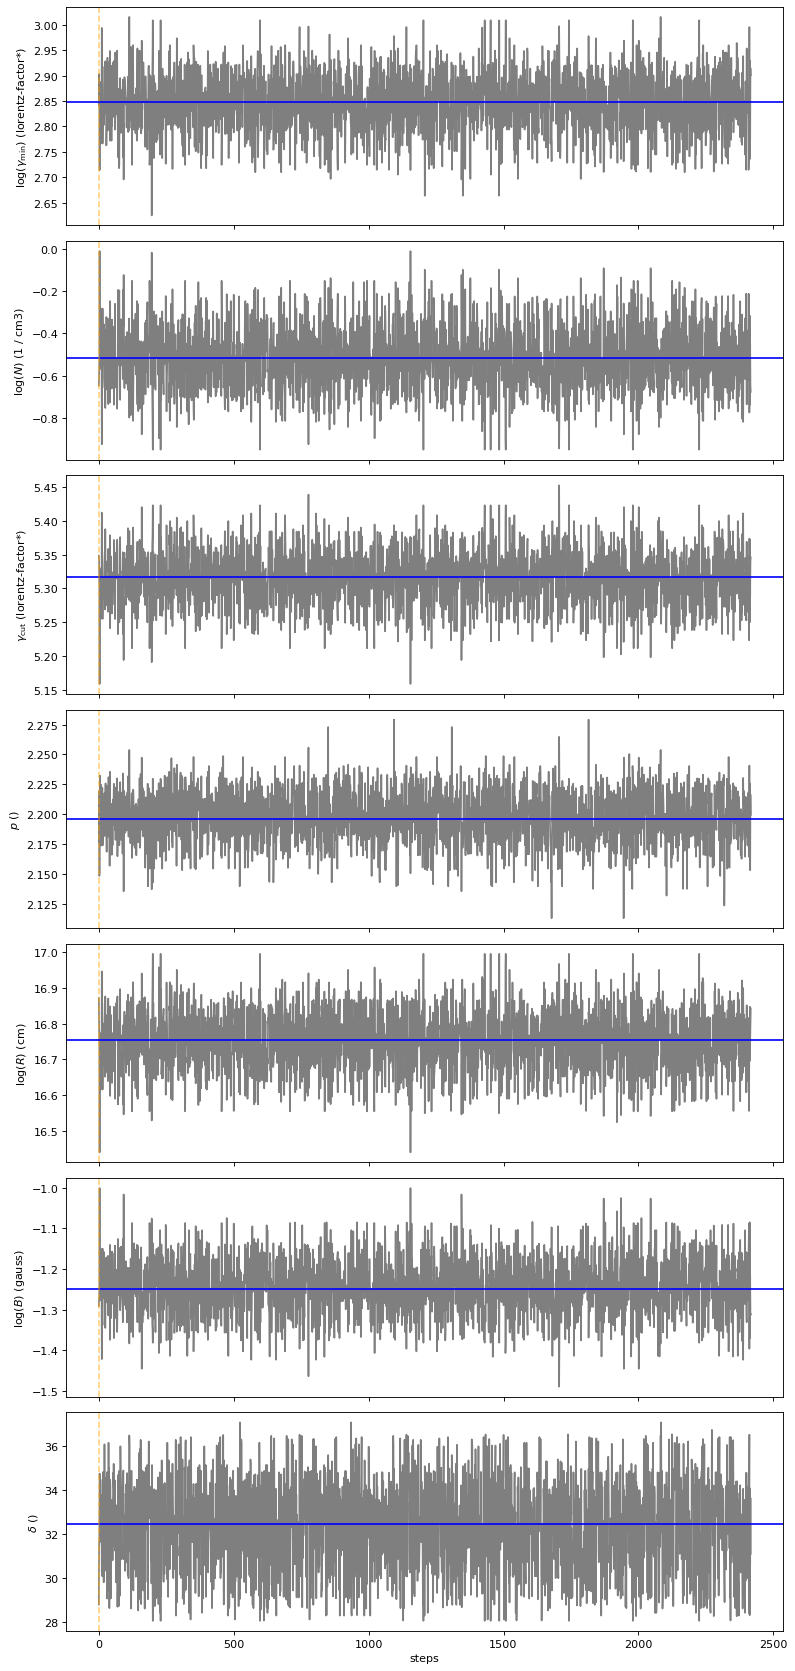

In [34]:
mpl.rcParams['figure.dpi'] = 80
f=mcmc.plot_chain(log_plot=False)
plt.tight_layout()

In [35]:
mcmc.save('mcmc_sampler_ultranest_plain_openmpi.pkl')

In [36]:
from jetset.mcmc import McmcSampler
from jetset.data_loader import ObsData

sed_data=ObsData.load('Mrk_401.pkl')
ms=McmcSampler.load('mcmc_sampler_ultranest_plain_openmpi.pkl')

import matplotlib as mpl


In [37]:
ms.sampler_parameters

model name,name,val,log,bestfit mcmc,q16,q50,q84,mcmc bound min,mcmc bound max,frozen
str12,str16,float64,bool,float64,float64,float64,float64,float64,float64,bool
jet_leptonic,gmin,2.862132e+00,True,2.862132e+00,2.793184e+00,2.847179e+00,2.901346e+00,0.000000e+00,3.300000e+00,False
jet_leptonic,N,-5.869194e-01,True,-5.869194e-01,-6.613947e-01,-5.177216e-01,-3.608506e-01,-3.000000e+00,3.000000e+00,False
jet_leptonic,gamma_cut,5.340953e+00,True,5.340953e+00,5.277429e+00,5.316390e+00,5.354219e+00,3.000000e+00,6.000000e+00,False
jet_leptonic,p,2.200548e+00,False,2.200548e+00,2.176658e+00,2.196339e+00,2.220571e+00,1.500000e+00,3.500000e+00,False
jet_leptonic,R,1.679884e+01,True,1.679884e+01,1.666789e+01,1.675326e+01,1.684003e+01,1.500000e+01,1.700000e+01,False
jet_leptonic,B,-1.290284e+00,True,-1.290284e+00,-1.314047e+00,-1.249120e+00,-1.174494e+00,-3.000000e+00,0.000000e+00,False
jet_leptonic,beam_obj,3.201161e+01,False,3.201161e+01,3.005475e+01,3.247335e+01,3.445879e+01,1.000000e+01,5.000000e+01,False
jet_leptonic,gmax,7.000000e+00,True,--,--,--,--,0.000000e+00,1.500000e+01,True
jet_leptonic,R_H,1.000000e+17,False,--,--,--,--,0.000000e+00,--,True


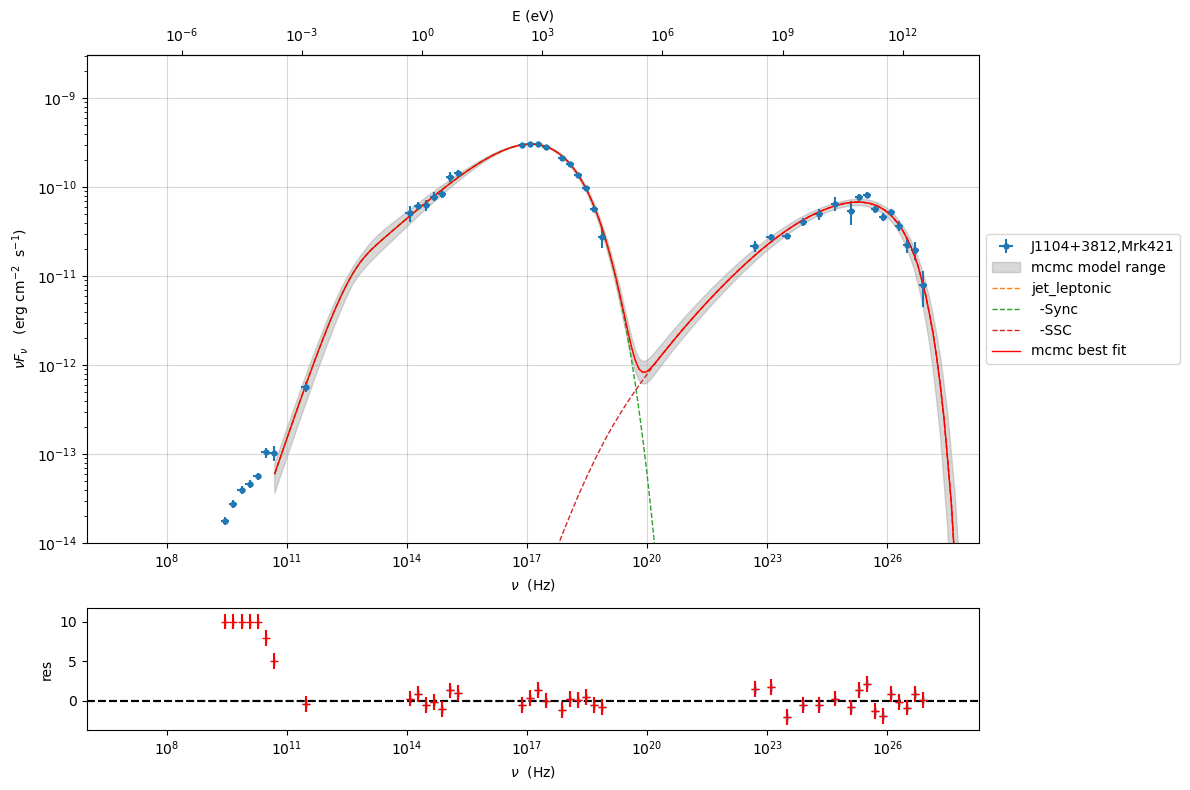

In [38]:
mpl.rcParams['figure.dpi'] = 80
p=ms.plot_model(sed_data=sed_data,fit_range=[1E7, 1E29],size=500,plot_components=True)
p.setlim(y_min=1E-14,x_min=1E6,x_max=2E28)

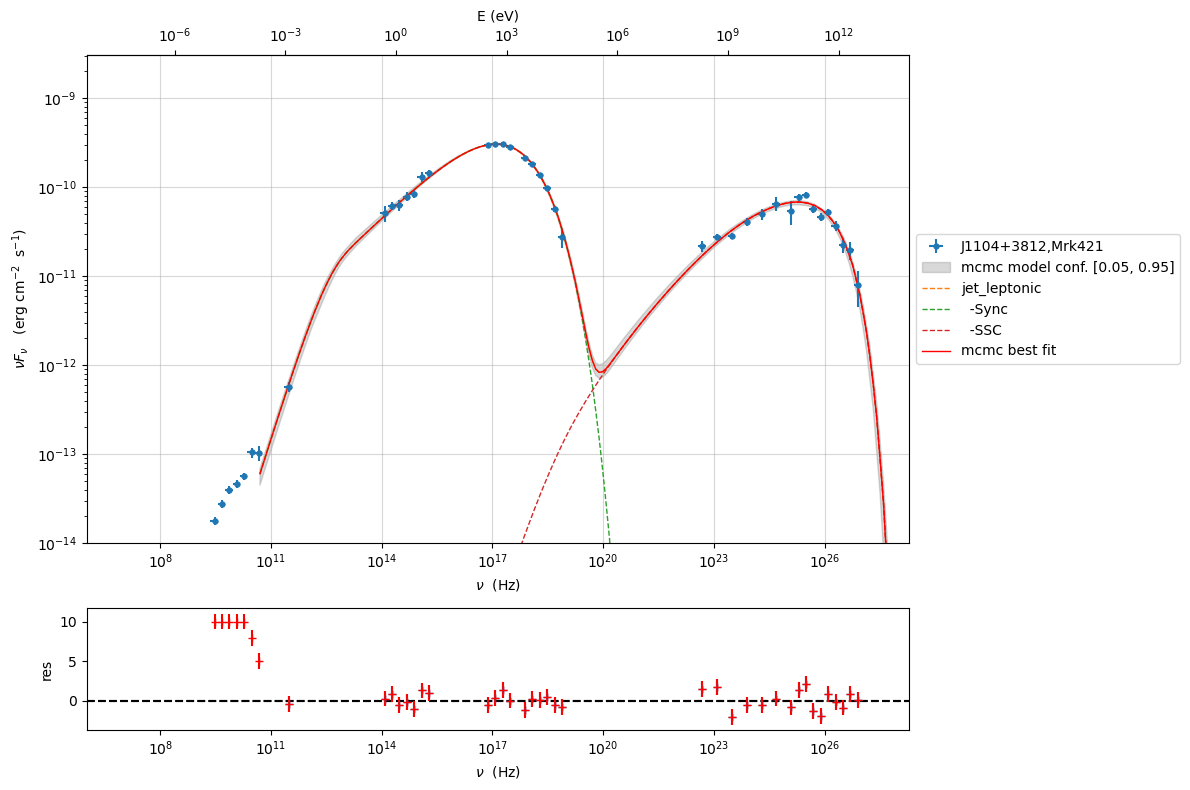

In [39]:
mpl.rcParams['figure.dpi'] = 80
p=ms.plot_model(sed_data=sed_data,fit_range=[1E7, 1E29],size=100,quantiles=[0.05,0.95],plot_components=True)
p.setlim(y_min=1E-14,x_min=1E6,x_max=2E28)

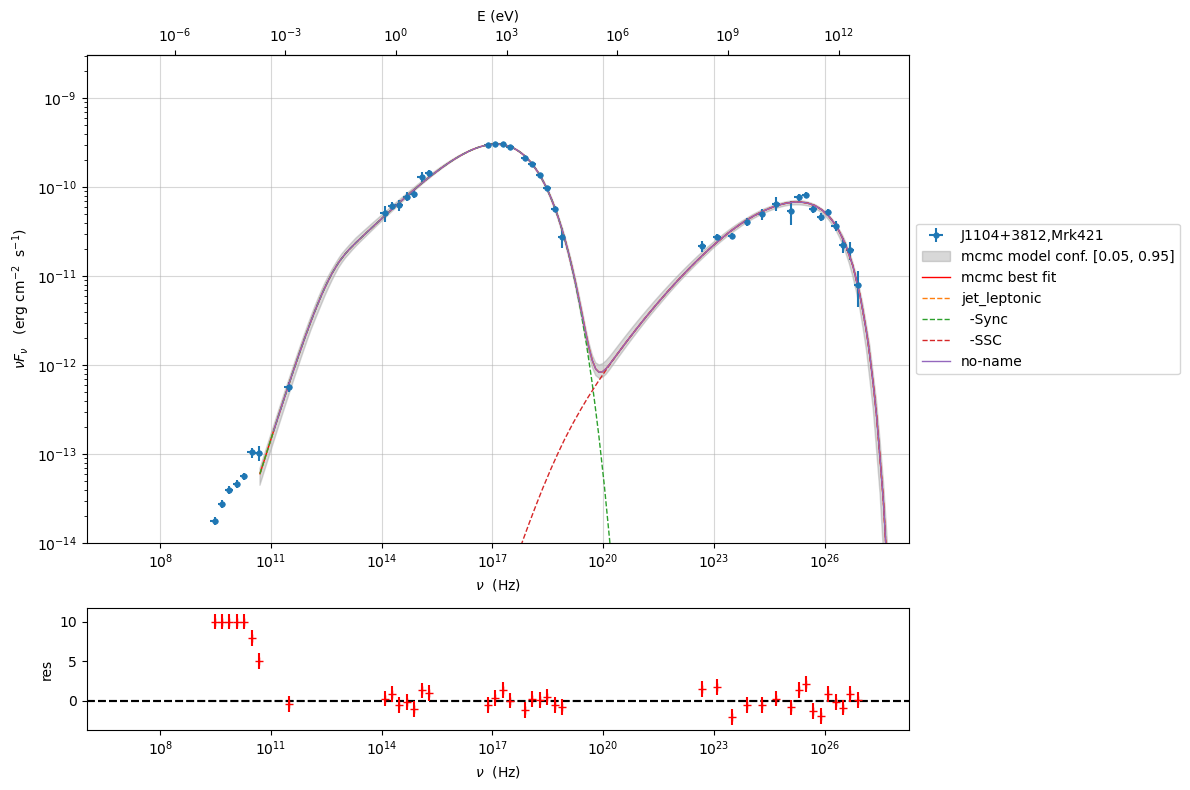

In [40]:
mpl.rcParams['figure.dpi'] = 80
p=ms.plot_model(sed_data=sed_data,fit_range=[1E7, 1E29],size=100,quantiles=[0.05,0.95],plot_mcmc_best_fit_model=True)
p=ms.model.plot_model(plot_obj=p)
p.setlim(y_min=1E-14,x_min=1E6,x_max=2E28)

Per-component corner plot

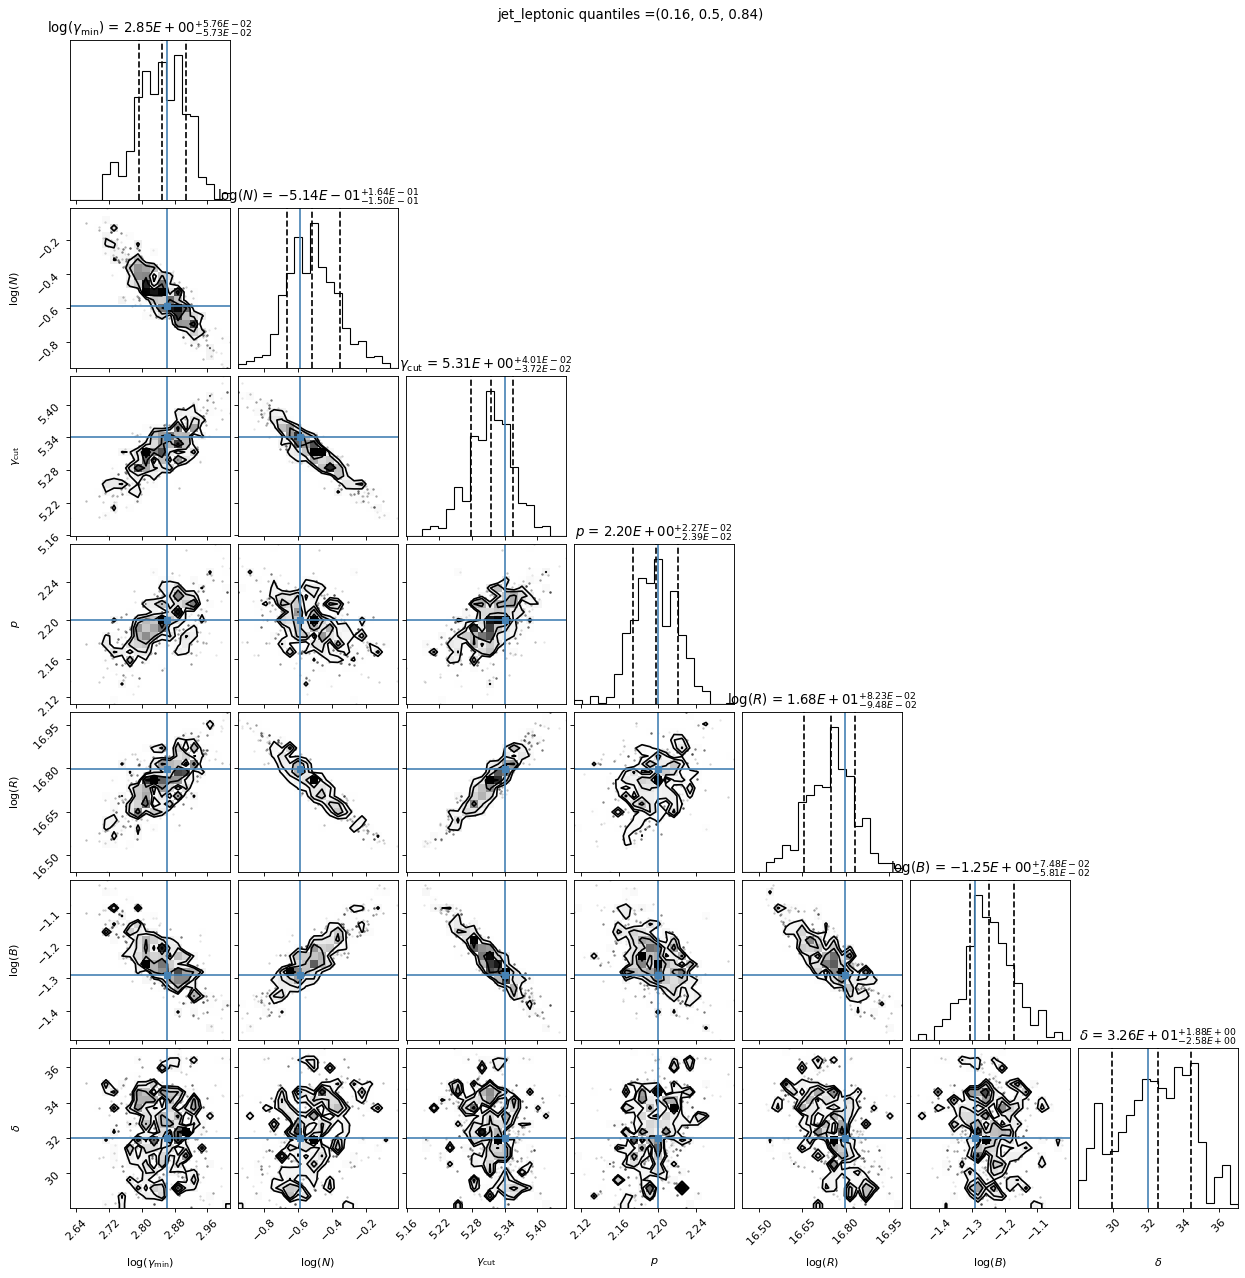

In [41]:
mpl.rcParams['figure.dpi'] = 80
f=ms.corner_plot(quantiles=(0.16, 0.5, 0.84),title_kwargs=dict(fontsize=12),title_fmt=".2E",use_math_text=True)

Global corner plot, pass `per_component=False`


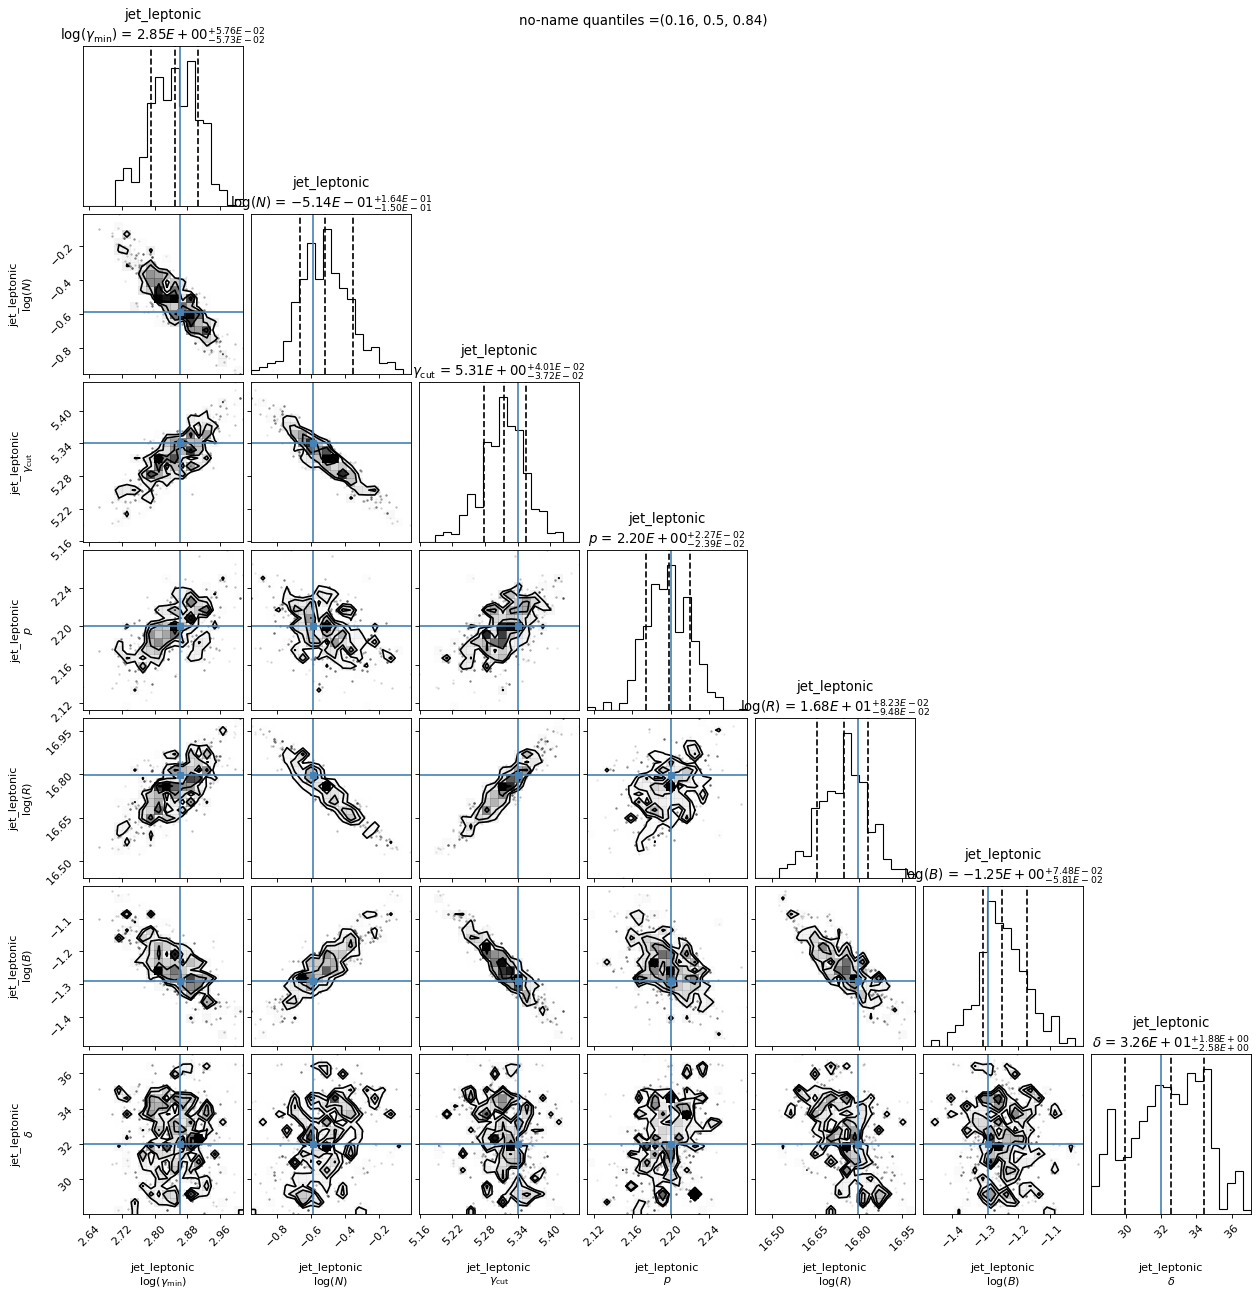

In [42]:
mpl.rcParams['figure.dpi'] = 80
f=ms.corner_plot(quantiles=(0.16, 0.5, 0.84),title_kwargs=dict(fontsize=12),title_fmt=".2E",use_math_text=True,per_component=False)